In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

### Softmax Function:

In [4]:
def softmax(z):
    """Compute softmax probabilities with numerical stability."""
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    softmax_probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    return softmax_probs

# Test softmax
z_test = np.array([[2.0, 1.0, 0.], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed! Row sums are {row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


Predict Function

In [5]:
def predict_softmax(X, W, b):
    """Predict class labels using softmax model."""
    z = np.dot(X, W) + b
    probs = softmax(z)
    predicted_classes = np.argmax(probs, axis=1)
    return predicted_classes

# Test predict
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed! Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


### Loss Function:

In [6]:
def loss_softmax(y_pred, y):
    """Cross-entropy loss for single sample."""
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]
    return loss

def cost_softmax(X, y, W, b):
    """Average cross-entropy cost over all samples."""
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n

# Test loss
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([[0.9, 0.05, 0.05], [0.1, 0.85, 0.05], [0.05, 0.1, 0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9], [0.1, 0.05, 0.85], [0.85, 0.1, 0.05]])
loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)
assert loss_correct < loss_incorrect, f"Test failed!"
print(f"Loss Correct: {loss_correct:.4f}, Loss Incorrect: {loss_incorrect:.4f}")

Loss Correct: 0.1435, Loss Incorrect: 2.9957


# Compute Gradients

In [7]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]

    # Step 1: Compute logits
    z = np.dot(X, W) + b

    # Step 2: Softmax predictions
    y_pred = softmax(z)

    # Step 3: Compute gradients
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b
    #test
    X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
gradW, gradb = compute_gradient_softmax(X_test, y_test, W_test, b_test)
print("Gradient w.r.t. W:\n", gradW)
print("Gradient w.r.t. b:", gradb)
print("Test passed!")

Gradient w.r.t. W:
 [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [8]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        # Step 1: Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Step 2: Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Step 3: Compute cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Optional: Print cost
        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")

    return W, b, cost_history

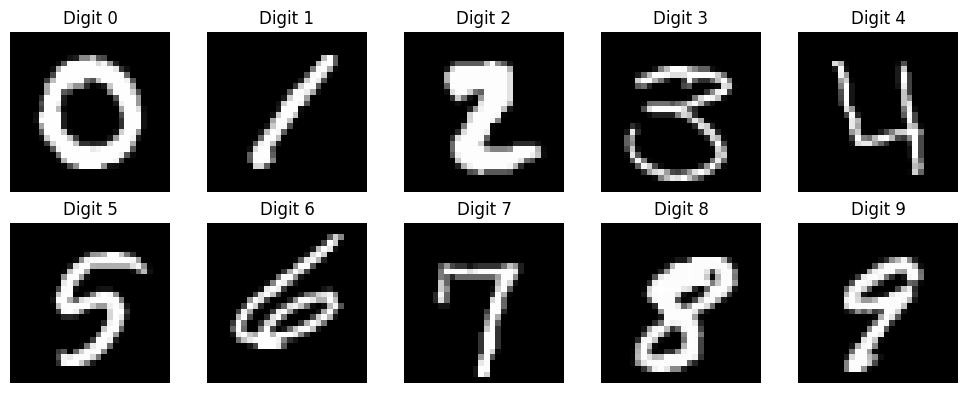

Training data shape: (33600, 784)
Test data shape: (8400, 784)


In [9]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """Load MNIST CSV and prepare data."""
    df = pd.read_csv(csv_file)
    y = df.iloc[:, 0].values  # First column is label
    X = df.iloc[:, 1:].values  # Rest are pixels
    X = X / 255.0  # Normalize
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Plot sample images
    def plot_sample_images(X, y):
        plt.figure(figsize=(10, 4))
        unique_classes = np.unique(y)
        for i, digit in enumerate(unique_classes[:10]):
            index = np.where(y == digit)[0][0]
            image = X[index].reshape(28, 28)
            plt.subplot(2, 5, i+1)
            plt.imshow(image, cmap='gray')
            plt.title(f'Digit {digit}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    plot_sample_images(X, y)
    return X_train, X_test, y_train, y_test

# Load data
csv_file = '/content/drive/MyDrive/Copy of mnist_train.csv'
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file)
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


Train Model

Question 1
Is extracting pixel values sufficient for effective feature extraction? Why or why not?

Extracting pixel values is sufficient for effective feature in our dataset because the dataset is clean and works for MNIST but for other image with curves and edges it won't be sufficient because the accuracy won't be high enough

Iteration 0, Cost: 2.2074
Iteration 100, Cost: 0.6007
Iteration 200, Cost: 0.4819
Iteration 300, Cost: 0.4326
Iteration 400, Cost: 0.4040
Iteration 500, Cost: 0.3847
Iteration 600, Cost: 0.3706
Iteration 700, Cost: 0.3597
Iteration 800, Cost: 0.3509
Iteration 900, Cost: 0.3436


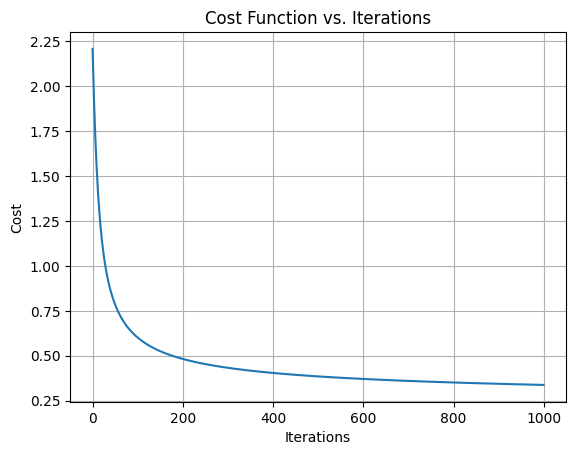

In [10]:
# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

# Initialize parameters
d, c = X_train.shape[1], y_train_encoded.shape[1]
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Train
alpha = 0.1
n_iter = 1000
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train_encoded, W, b, alpha, n_iter, show_cost=True)

# Plot cost
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

Evaluation

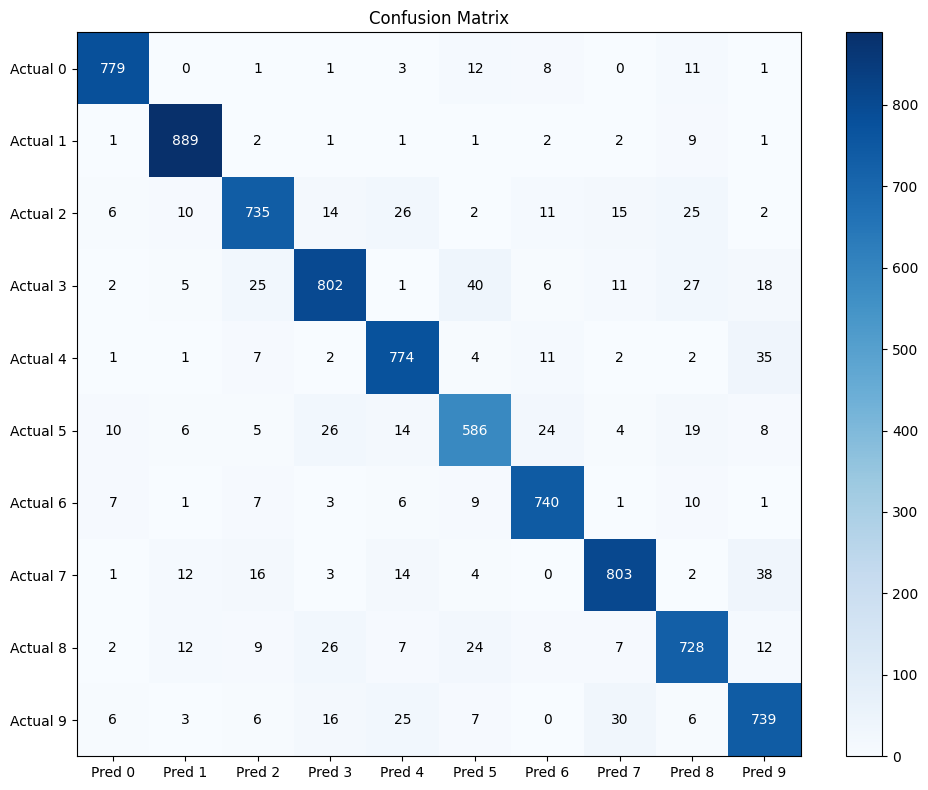

Confusion Matrix:
 [[779   0   1   1   3  12   8   0  11   1]
 [  1 889   2   1   1   1   2   2   9   1]
 [  6  10 735  14  26   2  11  15  25   2]
 [  2   5  25 802   1  40   6  11  27  18]
 [  1   1   7   2 774   4  11   2   2  35]
 [ 10   6   5  26  14 586  24   4  19   8]
 [  7   1   7   3   6   9 740   1  10   1]
 [  1  12  16   3  14   4   0 803   2  38]
 [  2  12   9  26   7  24   8   7 728  12]
 [  6   3   6  16  25   7   0  30   6 739]]
Precision: 0.90, Recall: 0.90, F1-Score: 0.90


In [11]:
def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Predict and evaluate
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
cm, precision, recall, f1 = evaluate_classification(y_test, y_pred_test)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=[f'Pred {i}' for i in range(cm.shape[0])],
       yticklabels=[f'Actual {i}' for i in range(cm.shape[0])],
       title='Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j]>np.max(cm)/2 else "black")
plt.tight_layout()
plt.show()

print("Confusion Matrix:\n", cm)
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

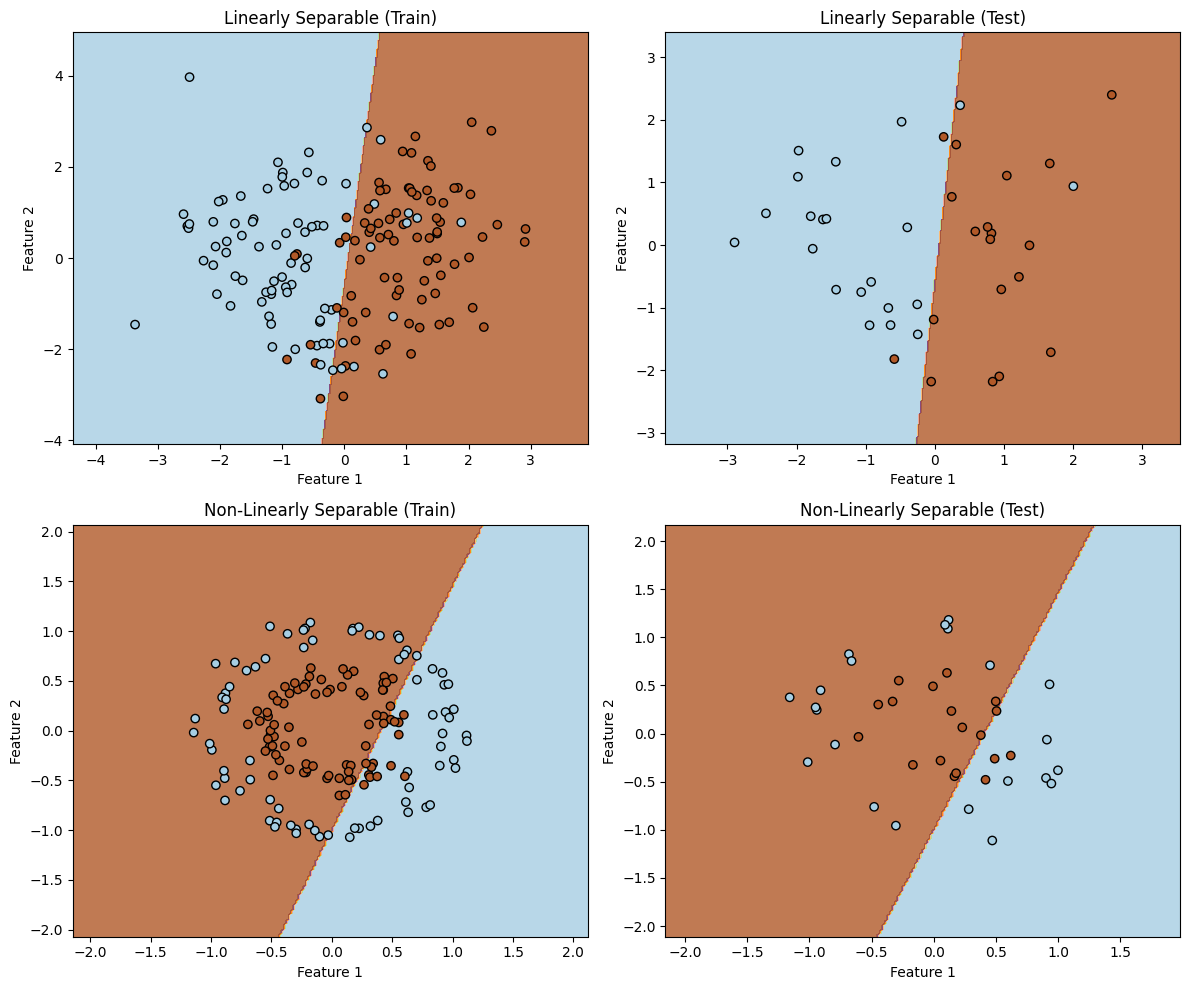

In [12]:
# Linear Separability Exercise - EXACT from worksheet
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    xmin, xmax = X[:, 0].min()-1, X[:, 0].max()+1
    ymin, ymax = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(xmin, xmax, h), np.arange(ymin, ymax, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

def plot_data_type(ax_row, data_gen_func, data_gen_kwargs, title_prefix, feature_subset=None):
    """Helper function to generate data, train model, and plot decision boundaries."""
    X, y = data_gen_func(**data_gen_kwargs)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Determine features for model training and plotting
    X_train_model = X_train[:, feature_subset] if feature_subset is not None else X_train
    X_test_model = X_test[:, feature_subset] if feature_subset is not None else X_test

    # Train the model
    model = LogisticRegression().fit(X_train_model, y_train)

    # Plot decision boundaries for training and testing sets
    plot_decision_boundary(ax_row[0], model, X_train_model, y_train, f'{title_prefix} (Train)')
    plot_decision_boundary(ax_row[1], model, X_test_model, y_test, f'{title_prefix} (Test)')

# Plotting Linear Data
plot_data_type(
    axes[0],
    make_classification,
    {'n_samples': 200, 'n_features': 4, 'n_informative': 2, 'random_state': 42},
    'Linearly Separable',
    feature_subset=[0, 1]
)

# Plotting Non-linear Data
plot_data_type(
    axes[1],
    make_circles,
    {'n_samples': 200, 'noise': 0.1, 'factor': 0.5, 'random_state': 42},
    'Non-Linearly Separable'
)

plt.tight_layout()
plt.show()




**Q2: Interpretation of plots?**  
- Sample images: Show clear MNIST digits (0-9).  
- Cost plot: Loss decreases, indicating the model converged.  
- Confusion matrix: Strong diagonal suggests good accuracy (around 90%).

**Q3: Challenges faced?**  
- Softmax numerical stability.  
- Ensuring correct matrix shape matches.  
- Finding an effective learning rate.  
- Managing memory for large datasets.